<a href="https://colab.research.google.com/github/orangecat24/DiabetesPredictionMLAlgorithms/blob/main/NeuralNetworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

selected_features = ['PhysHlth', 'GenHlth', 'MentHlth', 'BMI', 'DiffWalk', 'HighBP', 'HighChol', 'Age']
X_selected = X[selected_features]

# Normalize me standard scaler
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X_selected)

y = y['Diabetes_binary'].values

# Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42, stratify=y
)



Neural Network Architecture before pca and smote



In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

# Define parameter grid
hidden_layer_sizes = [(128,64), (64,32), (32,)]
activation_functions = ['relu', 'tanh', 'logistic']
learning_rates = ['constant', 'adaptive']
best_score_nn = 0
best_params_nn = None
best_model_nn = None

# Loop through parameter combinations
for hls in hidden_layer_sizes:
    for activation in activation_functions:
        for lr in learning_rates:
            print(f"Training with parameters: hidden_layer_sizes={hls}, activation={activation}, learning_rate={lr}")

            # Initialize the model with verbose logging
            nn_model = MLPClassifier(
                hidden_layer_sizes=hls,
                activation=activation,
                learning_rate=lr,
                max_iter=500,
                random_state=42,
                verbose=True  # Enable verbose output
            )
            # Train the model
            nn_model.fit(X_train, y_train)

            # Predict the test set
            y_pred = nn_model.predict(X_test)

            # Calculate accuracy
            accuracy = accuracy_score(y_test, y_pred)
            class_rep = classification_report(y_test, y_pred)

            print(f"Model accuracy: {accuracy}")
            print("Classification Report:\n", class_rep)
            print("\n" + "-"*50 + "\n")

            # Save the best parameters and model
            if accuracy > best_score_nn:
                best_score_nn = accuracy
                best_params_nn = {'hidden_layer_sizes': hls, 'activation': activation, 'learning_rate': lr}
                best_model_nn = nn_model

# Display the best parameters and accuracy
print("Best Neural Network Parameters:", best_params_nn)
print("Best Neural Network Accuracy:", best_score_nn)


Training with parameters: hidden_layer_sizes=(128, 64), activation=relu, learning_rate=constant
Iteration 1, loss = 0.32325349
Iteration 2, loss = 0.31697696
Iteration 3, loss = 0.31660214
Iteration 4, loss = 0.31627175
Iteration 5, loss = 0.31587032
Iteration 6, loss = 0.31570343
Iteration 7, loss = 0.31569473
Iteration 8, loss = 0.31553344
Iteration 9, loss = 0.31540532
Iteration 10, loss = 0.31542343
Iteration 11, loss = 0.31535122
Iteration 12, loss = 0.31515247
Iteration 13, loss = 0.31510991
Iteration 14, loss = 0.31511670
Iteration 15, loss = 0.31488651
Iteration 16, loss = 0.31482959
Iteration 17, loss = 0.31484597
Iteration 18, loss = 0.31478602
Iteration 19, loss = 0.31459094
Iteration 20, loss = 0.31457527
Iteration 21, loss = 0.31446496
Iteration 22, loss = 0.31453049
Iteration 23, loss = 0.31444399
Iteration 24, loss = 0.31438967
Iteration 25, loss = 0.31428045
Iteration 26, loss = 0.31430894
Iteration 27, loss = 0.31429028
Iteration 28, loss = 0.31418461
Iteration 29, los

Visualizing NN Results


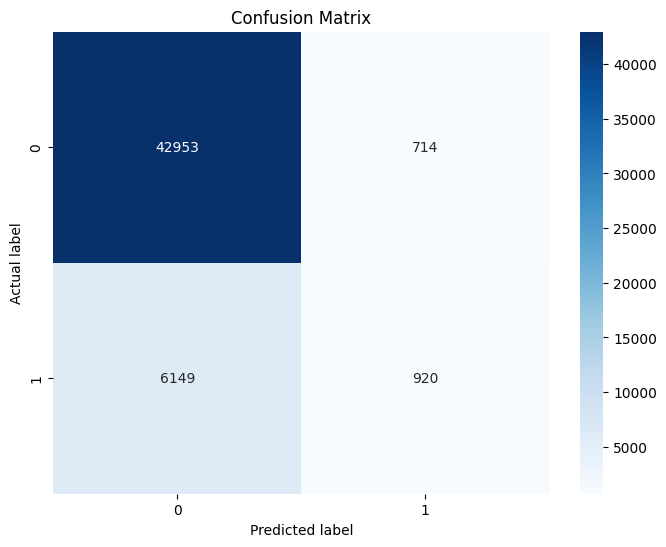

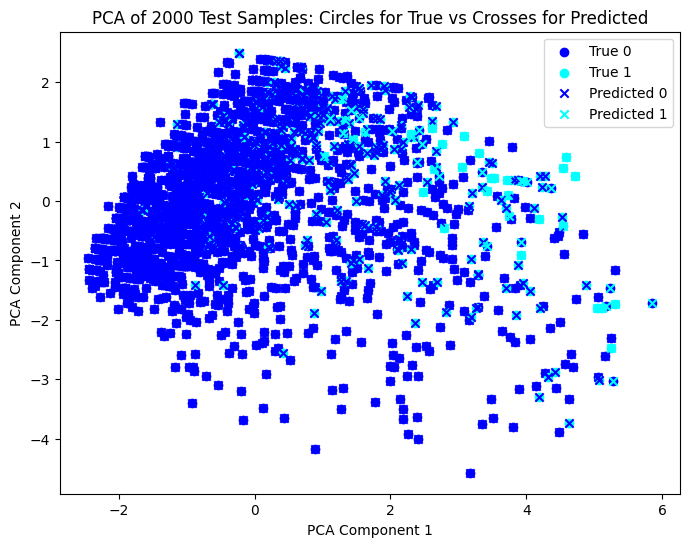

In [ ]:
y_pred_best = best_model_nn.predict(X_test)
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))
plt.title("Confusion Matrix")
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()


import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# Example data: X_test and labels (y_test, y_pred).
# Replace these with your actual test features and labels.
# ---------------------------------------------------------
n_test_samples = 2000
X_test_subset = X_test[:n_test_samples]
y_test_subset = y_test[:n_test_samples]
y_pred_subset = y_pred_best[:n_test_samples]  # from your trained model

# ---------------------------------------------------------
# 1. Perform PCA to reduce to 2 components
# ---------------------------------------------------------
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_subset)  # shape: (100, 2)

# ---------------------------------------------------------
# 2. Plot PCA (True labels = circles, Predicted labels = crosses)
#    Class 0 = dark blue, Class 1 = cyan
# ---------------------------------------------------------

plt.figure(figsize=(8,6))

# True class 0 (dark blue, circle)
plt.scatter(
    X_test_pca[y_test_subset == 0, 0],
    X_test_pca[y_test_subset == 0, 1],
    c='blue',            # dark blue
    marker='o',
    label='True 0'
)

# True class 1 (cyan, circle)
plt.scatter(
    X_test_pca[y_test_subset == 1, 0],
    X_test_pca[y_test_subset == 1, 1],
    c='cyan',            # teal/cyan
    marker='o',
    label='True 1'
)

# Predicted class 0 (dark blue, cross)
plt.scatter(
    X_test_pca[y_pred_subset == 0, 0],
    X_test_pca[y_pred_subset == 0, 1],
    c='blue',
    marker='x',
    label='Predicted 0'
)

# Predicted class 1 (cyan, cross)
plt.scatter(
    X_test_pca[y_pred_subset == 1, 0],
    X_test_pca[y_pred_subset == 1, 1],
    c='cyan',
    marker='x',
    label='Predicted 1'
)

# ---------------------------------------------------------
# 3. Labeling and final touches
# ---------------------------------------------------------
plt.title('PCA of 2000 Test Samples: Circles for True vs Crosses for Predicted')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()




Epoch 1/39 - Loss: 0.3141, Test Accuracy: 0.8647
Epoch 2/39 - Loss: 0.3141, Test Accuracy: 0.8643
Epoch 3/39 - Loss: 0.3141, Test Accuracy: 0.8643
Epoch 4/39 - Loss: 0.3140, Test Accuracy: 0.8644
Epoch 5/39 - Loss: 0.3140, Test Accuracy: 0.8646
Epoch 6/39 - Loss: 0.3139, Test Accuracy: 0.8646
Epoch 7/39 - Loss: 0.3139, Test Accuracy: 0.8645
Epoch 8/39 - Loss: 0.3139, Test Accuracy: 0.8643
Epoch 9/39 - Loss: 0.3139, Test Accuracy: 0.8645
Epoch 10/39 - Loss: 0.3138, Test Accuracy: 0.8643
Epoch 11/39 - Loss: 0.3138, Test Accuracy: 0.8644
Epoch 12/39 - Loss: 0.3138, Test Accuracy: 0.8644
Epoch 13/39 - Loss: 0.3138, Test Accuracy: 0.8645
Epoch 14/39 - Loss: 0.3137, Test Accuracy: 0.8646
Epoch 15/39 - Loss: 0.3137, Test Accuracy: 0.8645
Epoch 16/39 - Loss: 0.3137, Test Accuracy: 0.8647
Epoch 17/39 - Loss: 0.3137, Test Accuracy: 0.8647
Epoch 18/39 - Loss: 0.3137, Test Accuracy: 0.8646
Epoch 19/39 - Loss: 0.3136, Test Accuracy: 0.8648
Epoch 20/39 - Loss: 0.3136, Test Accuracy: 0.8645
Epoch 21/

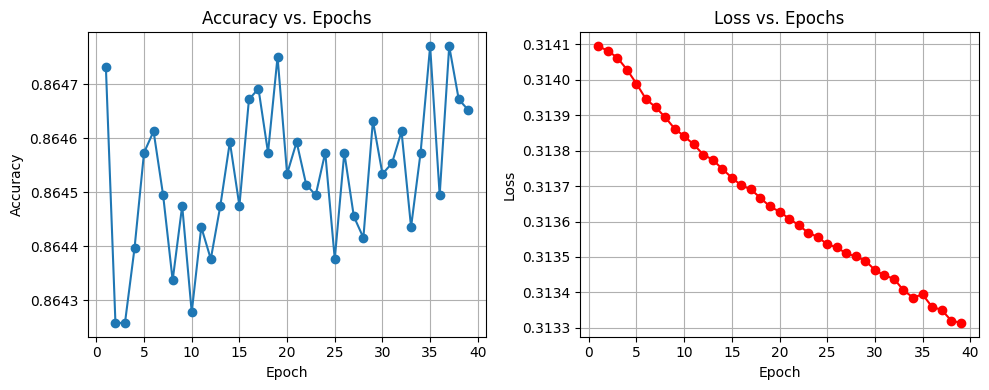

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score


# 3. Initialize the MLPClassifier with the given parameters and warm_start enabled
mlp = MLPClassifier(hidden_layer_sizes=(64, 32),
                    activation='relu',
                    learning_rate='constant',
                    warm_start=True,        # Allows training to continue over multiple .fit() calls
                    max_iter=39,             # We'll manually control the number of epochs
                    random_state=42)

# 4. Define number of epochs and prepare lists to store accuracy and loss
epochs = 39
accuracy_list = []
loss_list = []

# 5. Train iteratively, one epoch at a time
for epoch in range(epochs):
    # Perform one epoch of training
    mlp.fit(X_train, y_train)

    # Record the training loss from the model
    loss_list.append(mlp.loss_)

    # Evaluate accuracy on the test set (or validation set)
    y_pred = mlp.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_list.append(acc)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {mlp.loss_:.4f}, Test Accuracy: {acc:.4f}")

# 6. Plot accuracy over epochs
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), accuracy_list, marker='o')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# 7. Plot loss over epochs
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), loss_list, marker='o', color='red')
plt.title('Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()


Class distribution in training set before SMOTE:
0    0.860666
1    0.139334
Name: proportion, dtype: float64

Data successfully split into training and testing sets.
Training features shape: (202944, 8)
Testing features shape: (50736, 8)
Training labels shape: (202944,)
Testing labels shape: (50736,)
Class distribution in training set after SMOTE:
0    0.5
1    0.5
Name: proportion, dtype: float64


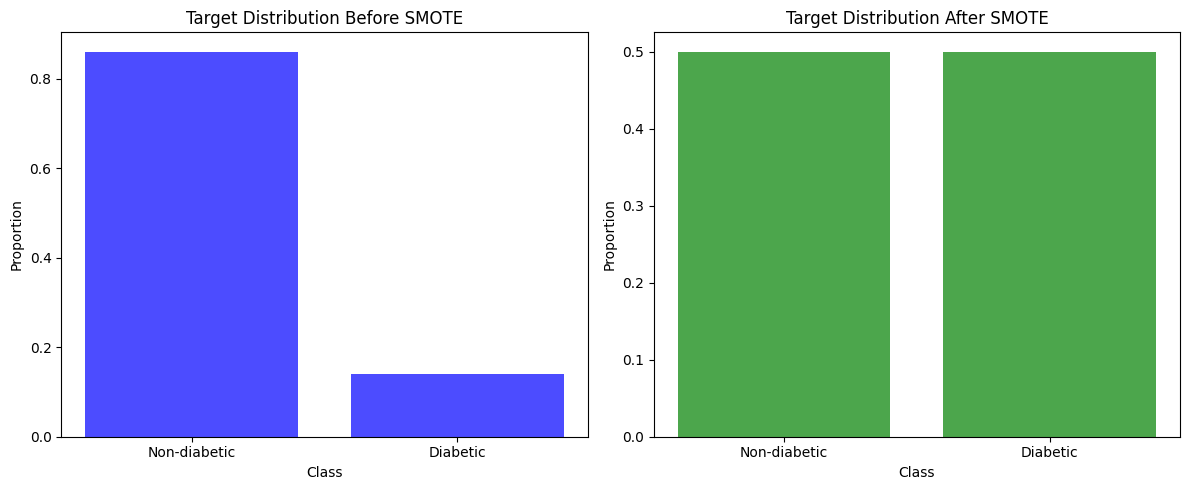

In [ ]:
print("Class distribution in training set before SMOTE:")
before_smote_distribution = pd.Series(y_train).value_counts(normalize=True)
print(before_smote_distribution)

print("\nData successfully split into training and testing sets.")
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)
# y_train = y_train.values.ravel()
# y_test = y_test.values.ravel()

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)


print("Class distribution in training set after SMOTE:")
after_smote_distribution = pd.Series(y_train_balanced).value_counts(normalize=True)
print(after_smote_distribution)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Before using SMOTE sampling
ax[0].bar(before_smote_distribution.index, before_smote_distribution.values, color='blue', alpha=0.7)
ax[0].set_title("Target Distribution Before SMOTE")
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['Non-diabetic', 'Diabetic'])
ax[0].set_ylabel("Proportion")
ax[0].set_xlabel("Class")

# After SMOTE sampling
ax[1].bar(after_smote_distribution.index, after_smote_distribution.values, color='green', alpha=0.7)
ax[1].set_title("Target Distribution After SMOTE")
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(['Non-diabetic', 'Diabetic'])
ax[1].set_ylabel("Proportion")
ax[1].set_xlabel("Class")

plt.tight_layout()
plt.show()

Visualizing the Scatter Plot for PCA


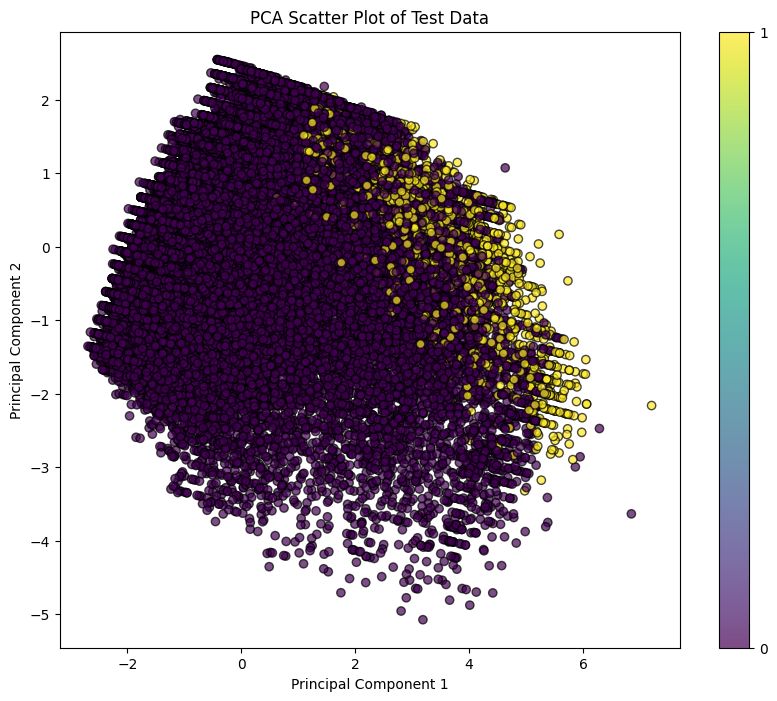

In [ ]:
from sklearn.decomposition import PCA

# Reduce dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test)  # Use only test data to avoid leakage

# Scatter plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred_best, cmap='viridis', edgecolor='k', alpha=0.7)
plt.title('PCA Scatter Plot of Test Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, ticks=np.unique(y_pred_best))
plt.show()


USING SMOTE AND PCA on NEURAL NETWORK ARCHITECTURE

In [ ]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_balanced)
X_test_pca = pca.transform(X_test)


# Define parameter grid
hidden_layer_sizes = [(128,64), (64,32), (32,)]
activation_functions = ['relu', 'tanh', 'logistic']
learning_rates = ['constant', 'adaptive']
best_score_nn = 0
best_params_nn = None
best_model_nn = None

# Loop through parameter combinations
for hls in hidden_layer_sizes:
    for activation in activation_functions:
        for lr in learning_rates:
            print(f"Training with parameters: hidden_layer_sizes={hls}, activation={activation}, learning_rate={lr}")

            # Initialize the model with verbose logging
            nn_model2 = MLPClassifier(
                hidden_layer_sizes=hls,
                activation=activation,
                learning_rate=lr,
                max_iter=500,
                random_state=42,
                verbose=True  # Enable verbose output
            )
            # Train the model
            nn_model2.fit(X_train_pca, y_train_balanced)

            # Predict the test set
            y_pred = nn_model2.predict(X_test_pca)

            # Calculate accuracy
            accuracy = accuracy_score(y_test, y_pred)
            class_rep = classification_report(y_test, y_pred)

            print(f"Model accuracy: {accuracy}")
            print("Classification Report:\n", class_rep)
            print("\n" + "-"*50 + "\n")

            # Save the best parameters and model
            if accuracy > best_score_nn:
                best_score_nn = accuracy
                best_params_nn = {'hidden_layer_sizes': hls, 'activation': activation, 'learning_rate': lr}
                best_model_nn2 = nn_model2

# Display the best parameters and accuracy
print("Best Neural Network Parameters:", best_params_nn)
print("Best Neural Network Accuracy:", best_score_nn)



Training with parameters: hidden_layer_sizes=(128, 64), activation=relu, learning_rate=constant
Iteration 1, loss = 0.53097844
Iteration 2, loss = 0.52860550
Iteration 3, loss = 0.52851735
Iteration 4, loss = 0.52828055
Iteration 5, loss = 0.52807157
Iteration 6, loss = 0.52792108
Iteration 7, loss = 0.52787267
Iteration 8, loss = 0.52775426
Iteration 9, loss = 0.52775380
Iteration 10, loss = 0.52773563
Iteration 11, loss = 0.52758355
Iteration 12, loss = 0.52756655
Iteration 13, loss = 0.52743575
Iteration 14, loss = 0.52748039
Iteration 15, loss = 0.52743326
Iteration 16, loss = 0.52731964
Iteration 17, loss = 0.52729875
Iteration 18, loss = 0.52731334
Iteration 19, loss = 0.52713575
Iteration 20, loss = 0.52723249
Iteration 21, loss = 0.52712084
Iteration 22, loss = 0.52714397
Iteration 23, loss = 0.52711668
Iteration 24, loss = 0.52713135
Iteration 25, loss = 0.52702634
Iteration 26, loss = 0.52702171
Iteration 27, loss = 0.52704804
Iteration 28, loss = 0.52695842
Iteration 29, los

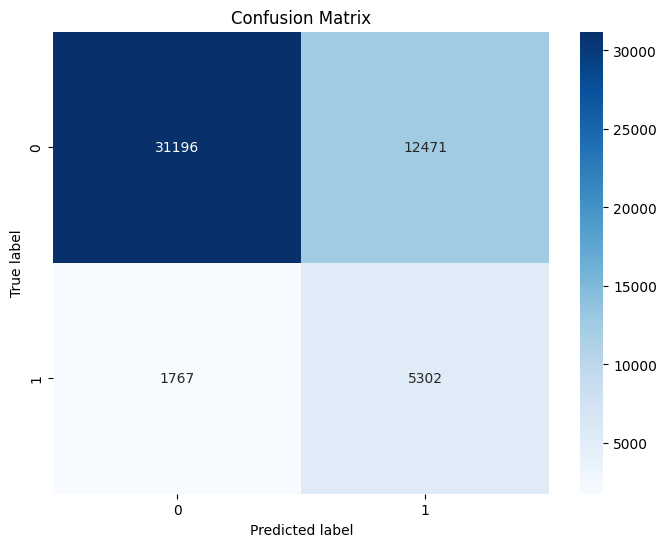

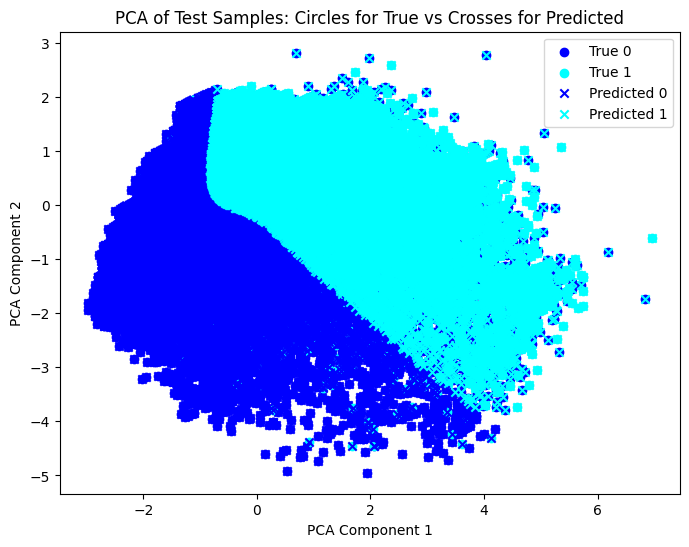

In [ ]:
y_pred_best = best_model_nn2.predict(X_test_pca)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_best)


# Optionally, plot the confusion matrix using seaborn for better visualization:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

plt.figure(figsize=(8, 6))

# True class 0 (blue, circle)
plt.scatter(
    X_test_pca[y_test == 0, 0],
    X_test_pca[y_test == 0, 1],
    c='blue',
    marker='o',
    label='True 0'
)

# True class 1 (cyan, circle)
plt.scatter(
    X_test_pca[y_test == 1, 0],
    X_test_pca[y_test == 1, 1],
    c='cyan',
    marker='o',
    label='True 1'
)

# Predicted class 0 (blue, cross)
plt.scatter(
    X_test_pca[y_pred_best == 0, 0],
    X_test_pca[y_pred_best == 0, 1],
    c='blue',
    marker='x',
    label='Predicted 0'
)

# Predicted class 1 (cyan, cross)
plt.scatter(
    X_test_pca[y_pred_best == 1, 0],
    X_test_pca[y_pred_best == 1, 1],
    c='cyan',
    marker='x',
    label='Predicted 1'
)

plt.title('PCA of Test Samples: Circles for True vs Crosses for Predicted')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()
plt.show()


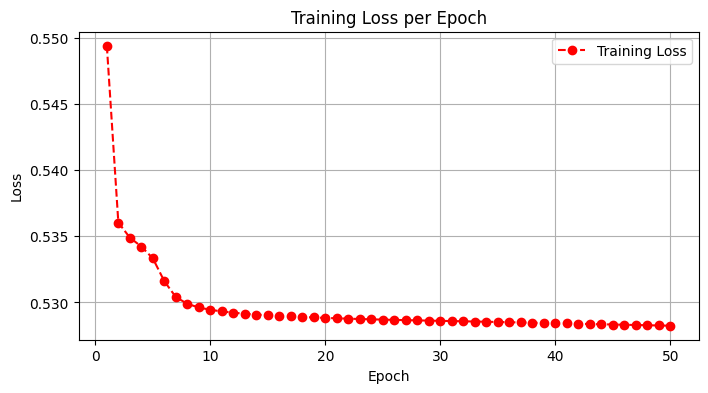

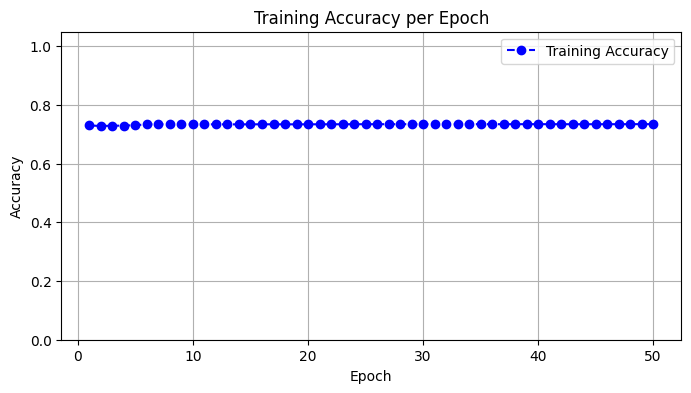

In [ ]:
# We retrieve the best hyperparameters and re-initialize with warm_start=True
best_hls = best_params_nn['hidden_layer_sizes']
best_activation = best_params_nn['activation']
best_lr = best_params_nn['learning_rate']

# We must specify 'max_iter=1' so that each call to partial_fit does exactly one "epoch"
mlp_for_curves = MLPClassifier(
    hidden_layer_sizes=best_hls,
    activation=best_activation,
    learning_rate=best_lr,
    warm_start=True,
    max_iter=1,         # 1 epoch per partial_fit call
    random_state=42
)

n_epochs = 50  # or choose how many epochs you want to illustrate
train_loss_curve = []
train_acc_curve = []

# partial_fit requires the list of all classes for classification
classes_ = np.unique(y_train_balanced)

for epoch in range(n_epochs):
    # One epoch of training
    mlp_for_curves.partial_fit(X_train_pca, y_train_balanced, classes=classes_)

    # Store the current training loss and accuracy
    # .loss_ is the current loss (after this epoch)
    train_loss_curve.append(mlp_for_curves.loss_)

    # .score(X, y) is the accuracy on the given dataset
    acc = mlp_for_curves.score(X_train_pca, y_train_balanced)
    train_acc_curve.append(acc)

# ---------------------------------------------------------
# 4. Plot the results
# ---------------------------------------------------------
epochs_range = range(1, n_epochs + 1)

# Plot Loss over epochs
plt.figure(figsize=(8, 4))
plt.plot(epochs_range, train_loss_curve, 'o--', color='red', label='Training Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot Accuracy over epochs
plt.figure(figsize=(8, 4))
plt.plot(epochs_range, train_acc_curve, 'o--', color='blue', label='Training Accuracy')
plt.title('Training Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1.05])  # so we can see if it hits 1.0
plt.legend()
plt.grid(True)
plt.show()

# **NAIVE BAYES**


Naive Bayes Classifier Results:
Accuracy: 0.8049
Confusion Matrix:
 [[37785  5882]
 [ 4016  3053]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.88     43667
           1       0.34      0.43      0.38      7069

    accuracy                           0.80     50736
   macro avg       0.62      0.65      0.63     50736
weighted avg       0.83      0.80      0.81     50736



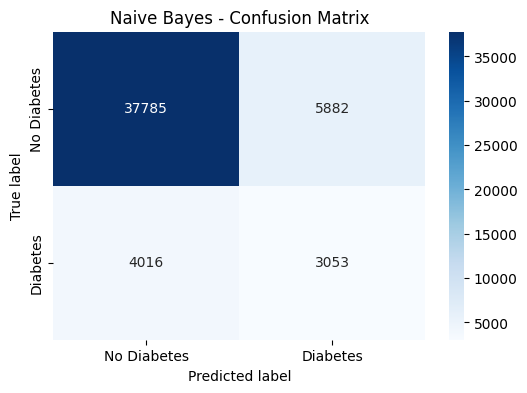

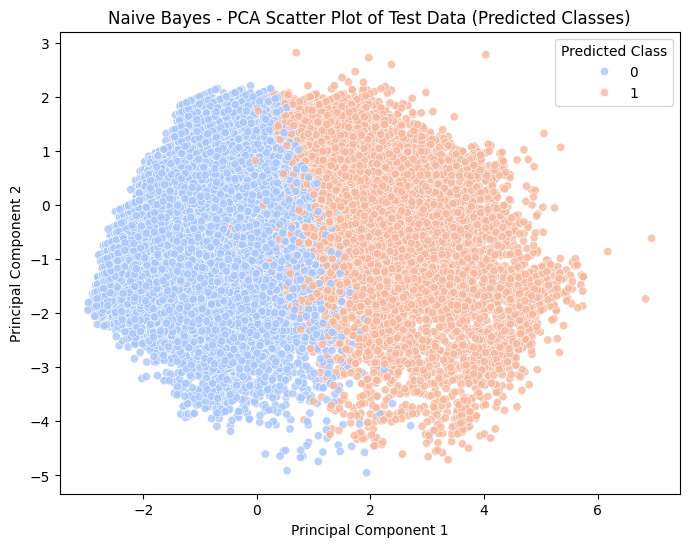

In [ ]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_balanced)
X_test_pca = pca.transform(X_test)

from sklearn.naive_bayes import GaussianNB

from sklearn.decomposition import PCA

nb_classifier = GaussianNB()

# 2. Fit the model on training data
nb_classifier.fit(X_train, y_train)

# 3. Predict on the test set
y_pred = nb_classifier.predict(X_test)

# 4. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_mat = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Naive Bayes Classifier Results:")
print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:\n", conf_mat)
print("Classification Report:\n", report)

# Optional: visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat, annot=True, cmap="Blues", fmt="d",
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title("Naive Bayes - Confusion Matrix")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_test_pca[:, 0],
    y=X_test_pca[:, 1],
    hue=y_pred,                 # color by predicted class
    palette="coolwarm",
    alpha=0.8
)

plt.title("Naive Bayes - PCA Scatter Plot of Test Data (Predicted Classes)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Predicted Class")
plt.show()

Using SMOTE and PCA


Naive Bayes Classifier Results:
Accuracy: 0.7298
Confusion Matrix:
 [[32041 11626]
 [ 2084  4985]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.73      0.82     43667
           1       0.30      0.71      0.42      7069

    accuracy                           0.73     50736
   macro avg       0.62      0.72      0.62     50736
weighted avg       0.85      0.73      0.77     50736



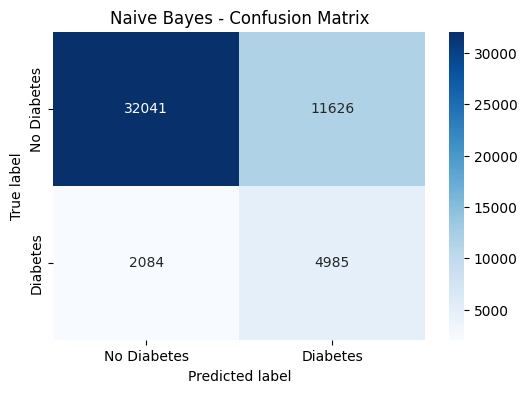

<Axes: >

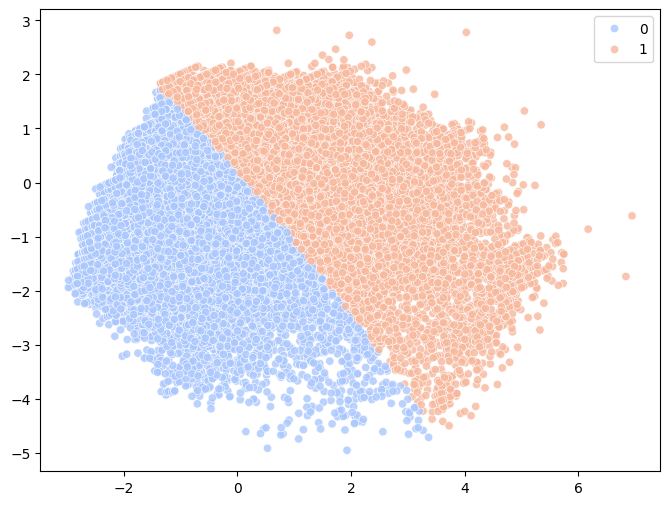

In [ ]:
nb_classifier.fit(X_train_pca, y_train_balanced)

# 3. Predict on the test set
y_pred = nb_classifier.predict(X_test_pca)

# 4. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_mat = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Naive Bayes Classifier Results:")
print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:\n", conf_mat)
print("Classification Report:\n", report)

# Optional: visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat, annot=True, cmap="Blues", fmt="d",
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title("Naive Bayes - Confusion Matrix")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_test_pca[:, 0],
    y=X_test_pca[:, 1],
    hue=y_pred,                 # color by predicted class
    palette="coolwarm",
    alpha=0.8
)


Ensemble Hybrid Model - Combining NN with NaiveBayes


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

# Ensure both models have been trained:
best_model_nn2.fit(X_train_pca, y_train_balanced)
nb_classifier.fit(X_train_pca, y_train_balanced)

# Get probability predictions from both models on the test set
probs_nn = best_model_nn2.predict_proba(X_test_pca)
probs_nb = nb_classifier.predict_proba(X_test_pca)

# Sum the probability outputs from both models
combined_probs = probs_nn + probs_nb

# For each sample, select the class with the highest combined probability
y_pred_ensemble = np.argmax(combined_probs, axis=1)

# Evaluate the ensemble performance
accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
print(f'Accuracy of Ensemble Model: {accuracy_ensemble:.2f}')

# Optionally, print confusion matrix and classification report for further evaluation
from sklearn.metrics import confusion_matrix, classification_report

conf_mat_ensemble = confusion_matrix(y_test, y_pred_ensemble)
report_ensemble = classification_report(y_test, y_pred_ensemble)
print("Confusion Matrix:\n", conf_mat_ensemble)
print("Classification Report:\n", report_ensemble)


Iteration 1, loss = 0.54938428
Iteration 2, loss = 0.53613767
Iteration 3, loss = 0.53492266
Iteration 4, loss = 0.53419875
Iteration 5, loss = 0.53341167
Iteration 6, loss = 0.53173331
Iteration 7, loss = 0.53047919
Iteration 8, loss = 0.53003976
Iteration 9, loss = 0.52968937
Iteration 10, loss = 0.52950660
Iteration 11, loss = 0.52935414
Iteration 12, loss = 0.52919576
Iteration 13, loss = 0.52916926
Iteration 14, loss = 0.52913484
Iteration 15, loss = 0.52902832
Iteration 16, loss = 0.52901037
Iteration 17, loss = 0.52899697
Iteration 18, loss = 0.52894782
Iteration 19, loss = 0.52891315
Iteration 20, loss = 0.52890306
Iteration 21, loss = 0.52881121
Iteration 22, loss = 0.52877507
Iteration 23, loss = 0.52881835
Iteration 24, loss = 0.52871991
Iteration 25, loss = 0.52871506
Iteration 26, loss = 0.52867381
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Accuracy of Ensemble Model: 0.73
Confusion Matrix:
 [[31607 12060]
 [ 1879  5190]]
Clas

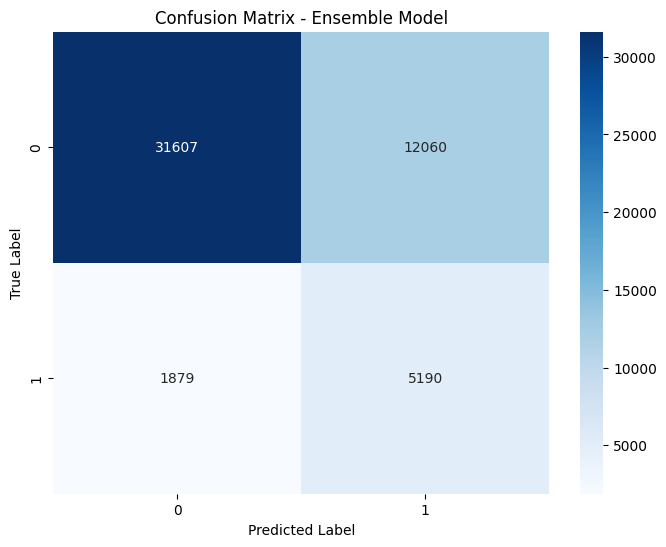

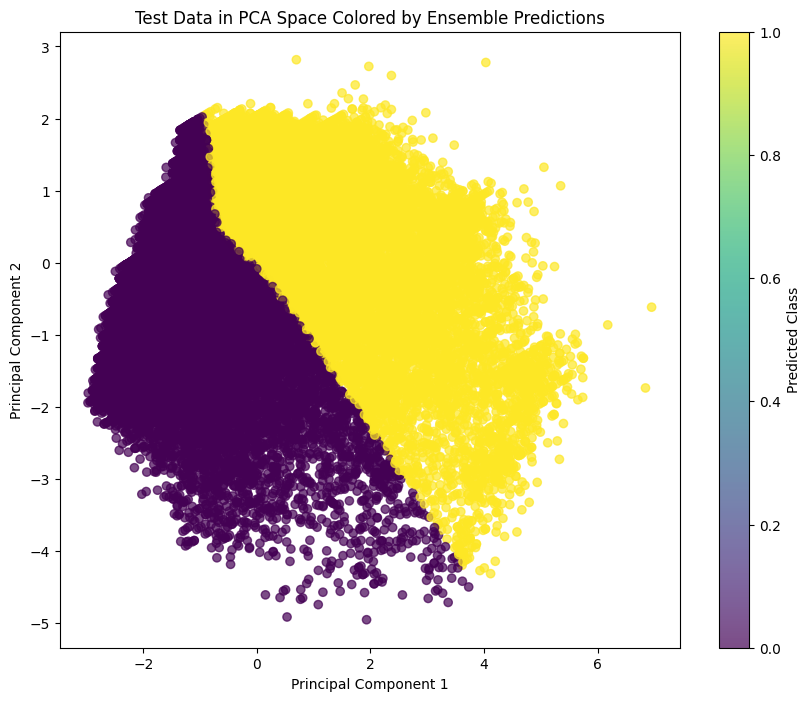

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix for the ensemble predictions
conf_mat_ensemble = confusion_matrix(y_test, y_pred_ensemble)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat_ensemble, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Confusion Matrix - Ensemble Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_pred_ensemble,  # Color points by the ensemble's predicted class
    cmap='viridis',
    alpha=0.7
)

plt.title('Test Data in PCA Space Colored by Ensemble Predictions')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Predicted Class')
plt.show()
